In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, PageBreak

sns.set_theme(style = "whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = "Data"
os.makedirs(DATA_DIR, exist_ok=True)

OUTPUT_DIR = "Output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OBSERVATIONS_FILE = os.path.join(DATA_DIR, "observations.csv")
SPECIES_INFO_FILE = os.path.join(DATA_DIR, "species_info.csv")

dfo = pd.read_csv(OBSERVATIONS_FILE)
dfs = pd.read_csv(SPECIES_INFO_FILE)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Introduction

<br>

In this project, I explore two datasets from the National Parks Conservation Association (NPCA):

• observations dataset (dfo): records species sightings across U.S. national parks over a 7-day period.

• species_info dataset (dfs): provides details on each species, including scientific name, common names,
conservation status, and biological category (e.g., mammal, bird, plant).

<br>

The goal is to create clear and engaging visuals that highlight endangered species, tailored for both expert
(scientific names) and lay audiences (common names).

Along the way, I also conduct exploratory analysis to see if the data reveals interesting patterns. While the
dataset is limited in scope (only a week of observations and no temporal trends), this project is meant to showcase
my data cleaning, analysis, and visualization methodology.


# Initial Cleaning and Analysis

After a quick inspection of the species_info dataset, I noticed some issues and took the following steps:
<br>

• There were multiple copies of values with the same species name and conservation status, but some slight variations
on their common names. So I am dropped the values with the same species name.

• The "common_names" column contains a list of common names assigned to each species. As the most commonly used
name was the first in the list, that is the one we will assign to applicable visualisations going forward.

• If a species is not under protection, the dataframe assigned a null value. Instead, I have assigned the value "Not of Concern" for future analysis.

• I split the DF into "protected" and "not protected" for initial and future analysis.

• Merged the cleaned species data with the observations data, joining on scientific name (Used in the "Examining Bat Populations" section).

In [9]:
dfs = dfs.drop_duplicates("scientific_name")
dfs["common_names"] = dfs["common_names"].apply(lambda x: x.split(",")[0])

dfs["conservation_status"] = dfs["conservation_status"].fillna("Not of Concern")
dfs["is_protected"] = dfs["conservation_status"] != "Not of Concern"

protected = dfs[dfs["conservation_status"] != "Not of Concern"]
not_protected = dfs[dfs["conservation_status"] == "Not of Concern"]

dfso = dfo.merge(dfs, how = "outer" ,on = "scientific_name").sort_values("park_name")

print("Number of protected species observed: ", len(protected))
print("Number of non-protected species observed: ", len(not_protected))

Number of protected species observed:  178
Number of non-protected species observed:  5363


While there are a large amount of species not in need of conservation, I want to examine the protected species by category, to understand the distribution better.

In [10]:
# Creating a pivot table to examine the count of protected and not protected species by category.
protected_count = (dfs.groupby(["category", "is_protected"])
                     .scientific_name.nunique()
                     .unstack(fill_value = 0)
                     .rename(columns = {"category": "Category", False: "Not Protected", True: "Protected"}))

protected_count["Percentage Under Protection"] = round(
    (protected_count["Protected"] /
     (protected_count["Protected"] + protected_count["Not Protected"])) * 100, 2)

protected_count_path = os.path.join(OUTPUT_DIR, "Protection Count by Species Category.csv")
protected_count.to_csv(protected_count_path, index=True)

protected_count

is_protected,Not Protected,Protected,Percentage Under Protection
category,,,
Amphibian,72,7,8.86
Bird,413,75,15.37
Fish,115,10,8.00
Mammal,146,30,17.05
Nonvascular Plant,328,5,1.50
Reptile,73,5,6.41
Vascular Plant,4216,46,1.08


Bird and Mammal species appear to have a much larger proportion of their population under the protected status. I will examine this later. For now, I'm going to create the visualisations for the endangered species.

# Producing Visualisations of the 14 endangered species

In [11]:
# Creating a DataFrame for to show only the endangered species
dfs_endangered = dfso[dfso["conservation_status"] == "Endangered"]

endangered_count = (dfs_endangered
                    .groupby(["common_names", "park_name", "category"])
                    .agg({"observations": "sum"}))

endangered_count_sci = (dfs_endangered
                    .groupby(["scientific_name", "park_name", "category"])
                    .agg({"observations": "sum"}))


endangered_count = endangered_count.reset_index()
endangered_count_sci = endangered_count_sci.reset_index()

In [12]:
# Ordering x-axis by the value of the observations from one national park, to ensure the two barplots will be identical
def order_smoky(df, col):
    """
    Create a barplot of endangered species observations by park.

    Parameters
    ----------
    df: pd.DataFrame
        DataFrame containing [species, park_name, observations].
    col: str
        Column to use for the x-axis (e.g. "common_names" or "scientific_name").
    """
    df = (df[df["park_name"] == "Great Smoky Mountains National Park"]
        .sort_values("observations", ascending=False)[col])
    return df

order = order_smoky(endangered_count, "common_names")
order_sci = order_smoky(endangered_count_sci, "scientific_name")


endangered_count_sorted = endangered_count.set_index("common_names").loc[order].reset_index()
endangered_count_sci_sorted = endangered_count_sci.set_index("scientific_name").loc[order_sci].reset_index()

Chart saved at Output\Endangered Observations Barplot - Common Name.png
Chart saved at Output\Endangered Observations Barplot - Scientific Name.png


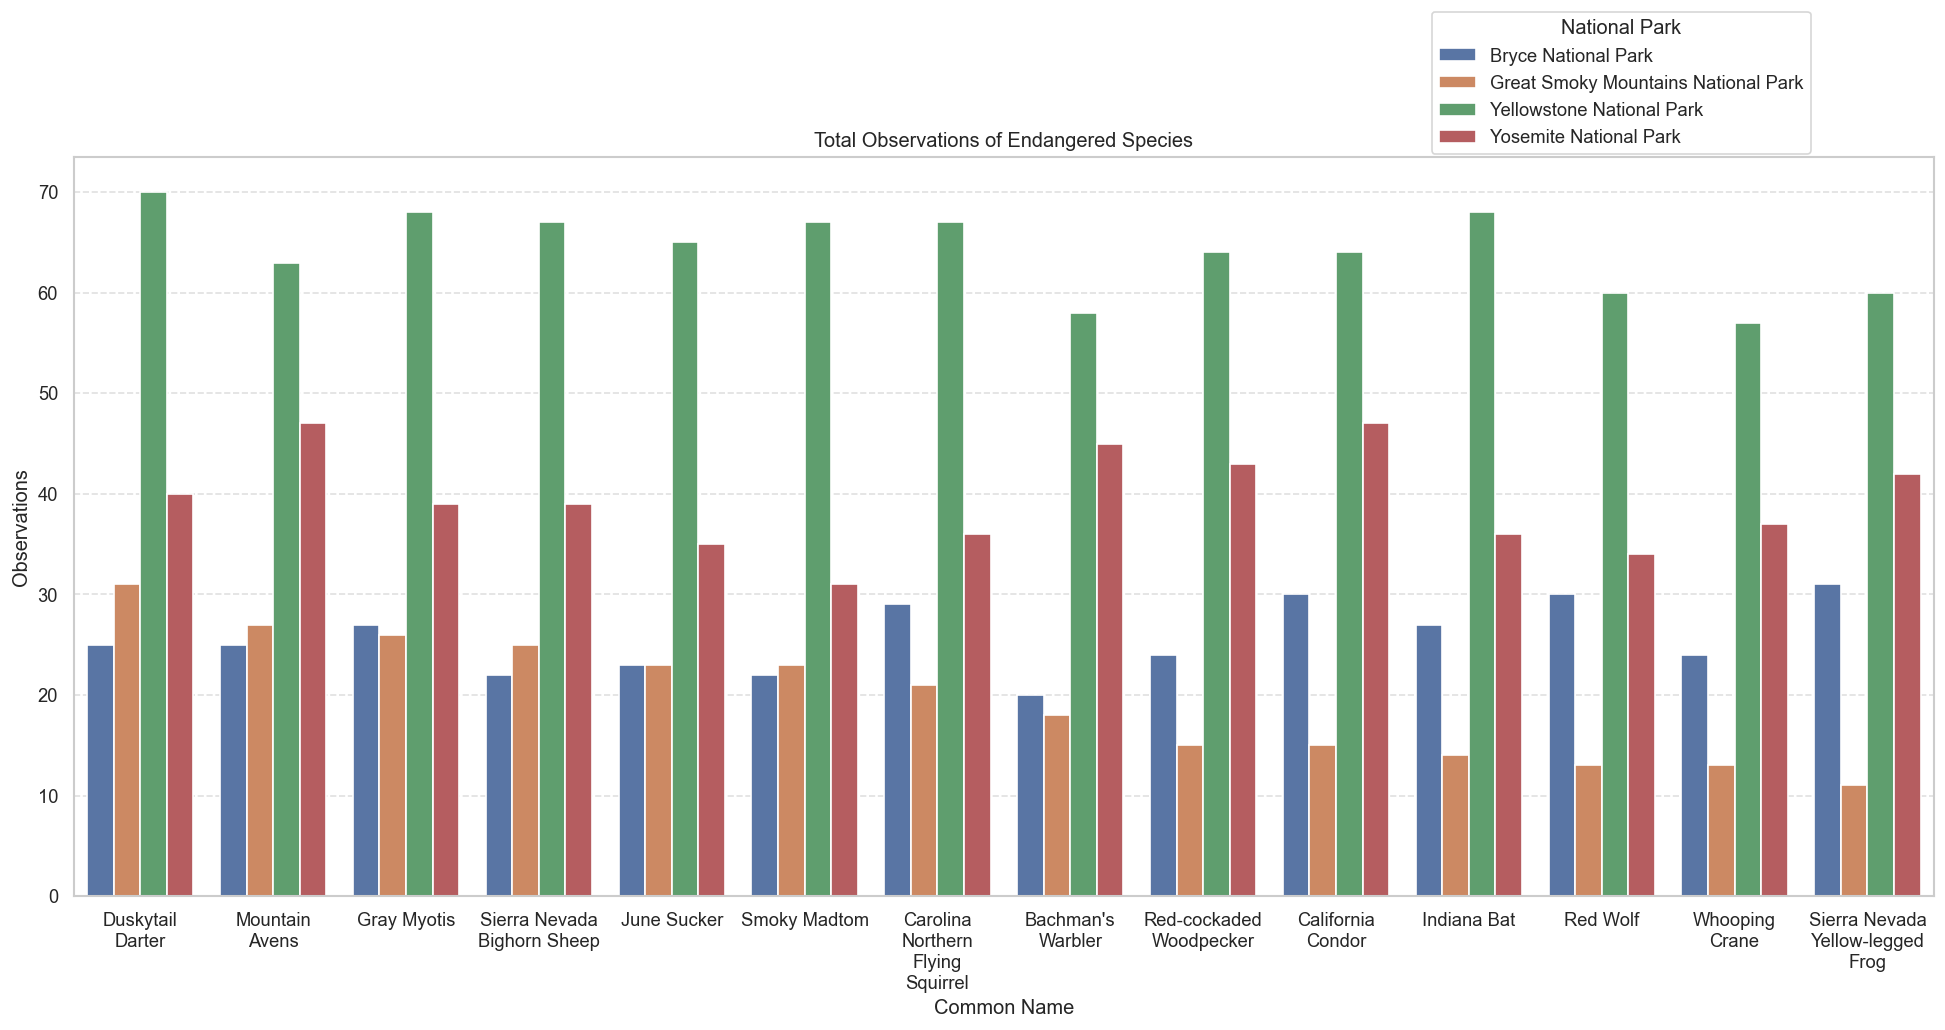

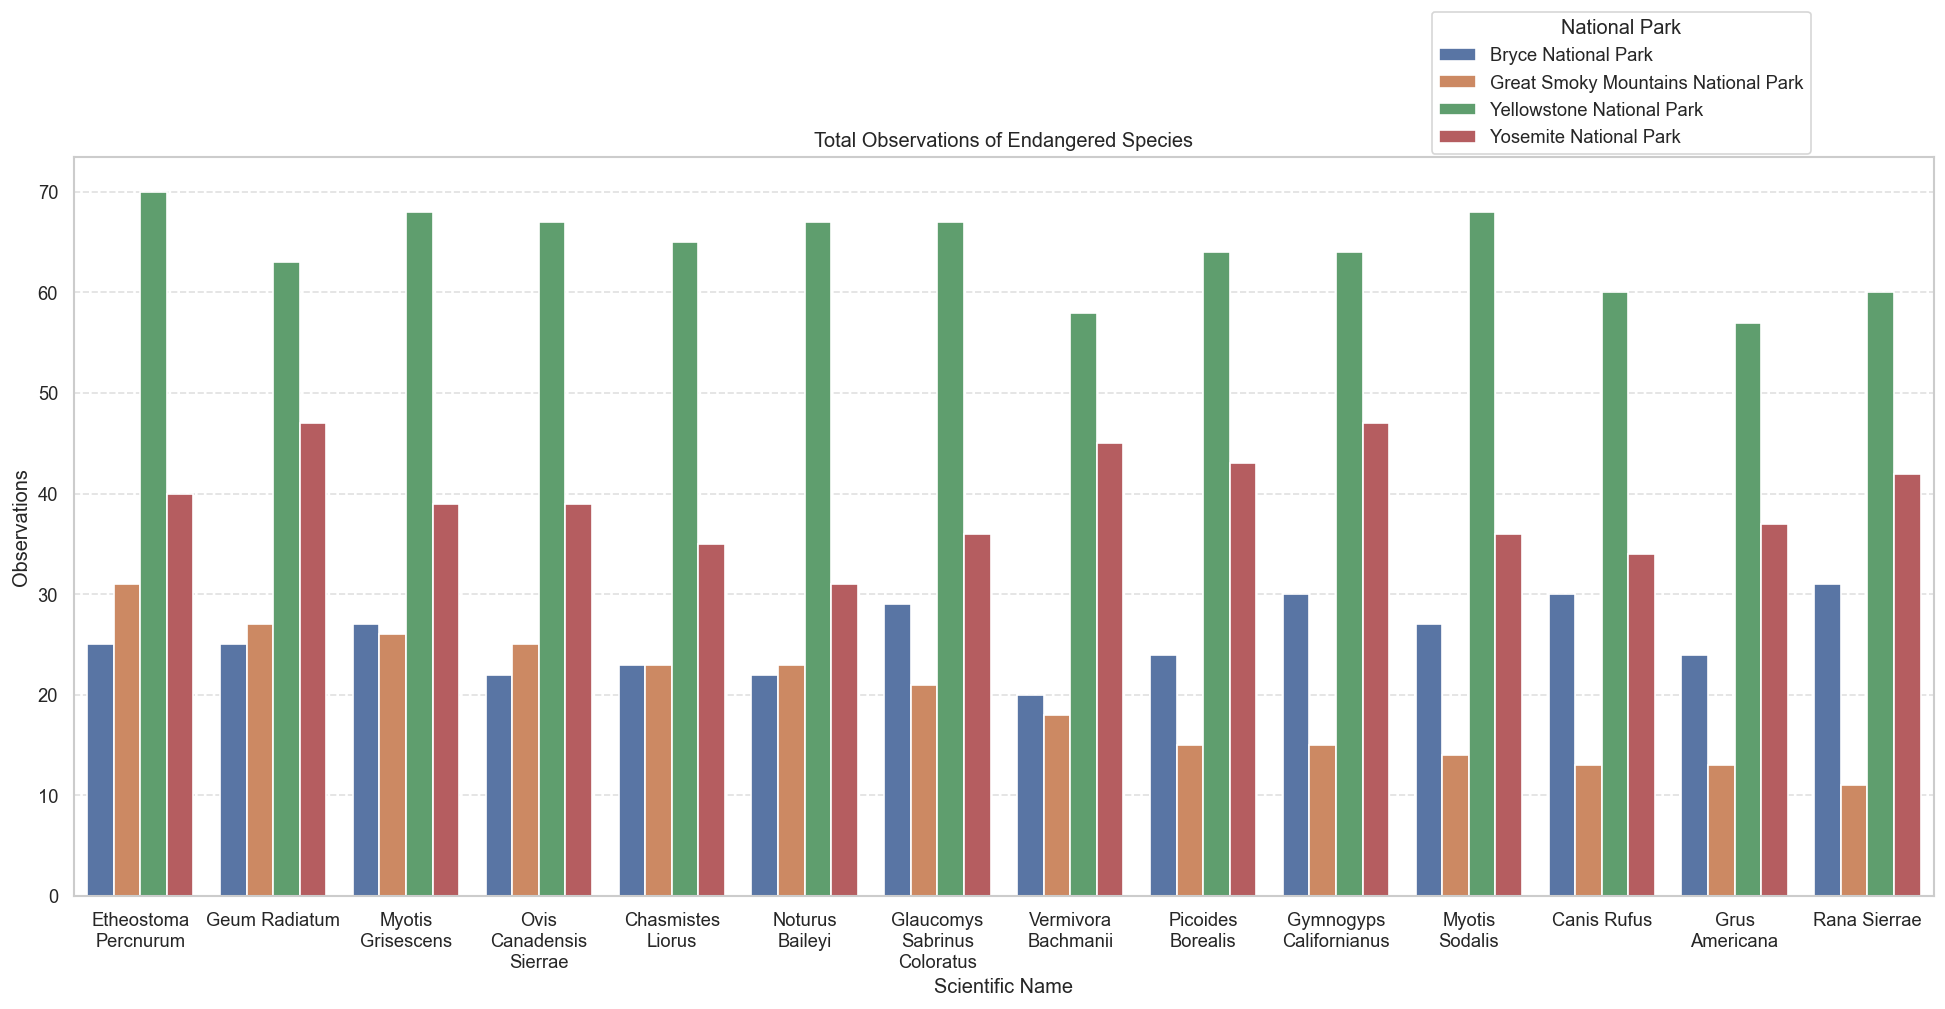

In [13]:
    # Barplot function
def endangered_barplot(data, x_axis_data, x_axis_name, file_path):
    """
    Create a barplot of endangered species observations by park.

    Parameters
    ----------
    data: pd.DataFrame
        DataFrame containing [species, park_name, observations].
    x_axis_data: str
        Column to use for the x-axis (e.g. "common_names" or "scientific_name").
    x_axis_name: str
        Axis label (Used in the plot).
    file_path: str
        Output filepath for the saved PNG chart.
    """

    plt.subplots(figsize = (20, 8))
    endangered_bar = sns.barplot(x = x_axis_data, y = "observations", data = data, hue = "park_name")

    # Wrapping and capitalizing the x-axis labels
    x_wrap = [
        textwrap.fill(
            " ".join([label.capitalize() for label in label.get_text().split()]), width=13)
        for label in endangered_bar.get_xticklabels()]

    # Applying to the barplot
    plt.xticks(ticks = endangered_bar.get_xticks(),
               labels = x_wrap)

    # Adding guidelines for ease of reading
    endangered_bar.yaxis.grid(True, linestyle="--", alpha=0.6)

    # Adding labels, and title. Also fixing legend positioning
    plt.xlabel(x_axis_name)
    plt.ylabel("Observations")
    plt.title("Total Observations of Endangered Species")
    plt.legend(
        title = "National Park",
        loc = "center left",
        bbox_to_anchor = (0.725, 1.1))

    plt.savefig(file_path, bbox_inches = "tight")
    print(f"Chart saved at {file_path}")

endangered_barplot(data = endangered_count_sorted, x_axis_data = "common_names", x_axis_name = "Common Name", file_path = os.path.join(OUTPUT_DIR, "Endangered Observations Barplot - Common Name.png"))
endangered_barplot(data = endangered_count_sci_sorted, x_axis_data = "scientific_name", x_axis_name = "Scientific Name", file_path = os.path.join(OUTPUT_DIR, "Endangered Observations Barplot - Scientific Name.png"))

In [14]:
# Masking repeated scientific/common names for table readability
def mask_names(df, col):
    """
    Create a barplot of endangered species observations by park.

    Parameters
    ----------
    df: pd.DataFrame
        DataFrame containing [species, park_name, observations].
    col: str
        The name of the column you want to mask.
    """
    df[col] = (df[col]
               .mask(df[col]
               .duplicated())
               .fillna(""))
    return df

common_masked = mask_names(endangered_count_sorted, "common_names")
sci_masked = mask_names(endangered_count_sci, "scientific_name")

In [15]:
def category_count_pdf(df, main_heading, category_column, file_path):
    """"
    Create a barplot of endangered species observations by park.

    Parameters
    ----------
    df: pd.DataFrame
        DataFrame containing [species, park_name, observations].
    main_heading: str
        The main heading of the PDF dcoument.
    category_column: str
        The name of the column the data will be pulled from.
    file_path: str
        Output filepath for the saved PDF.
    """

    # Create PDF document
    elements = []

    # Styles
    styles = getSampleStyleSheet()
    heading_style = ParagraphStyle(
        'Heading',
        parent = styles['Heading1'],
        alignment = 1,  # Centered
        spaceAfter = 5
    )
    subtitle_style = ParagraphStyle(
        'Subtitle',
        parent = styles['Heading2'],
        alignment = 1,
        spaceAfter = 12
    )

    elements.append(Paragraph(main_heading, heading_style))

    categories = df[category_column].unique()
    category_plural = []
    for category in categories:
        if category != "Fish":
            category = category + "s"
        category_plural.append(category)

    for i, (category, category_name) in enumerate(zip(categories, category_plural)):
        # Add subtitle (plural form for display)
        elements.append(Paragraph(str(category_name), subtitle_style))

        sub_df = df[df[category_column] == category].drop(columns = [category_column])

        data = [["Species Name", "Park Name", "Observation Count"]] + sub_df.values.tolist()

        table = Table(data, repeatRows = 1)
        table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.salmon),
            ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
            ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('BOTTOMPADDING', (0, 0), (-1, 0), 8),
            ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
        ]))

        elements.append(table)

        if i != len(categories) - 1:
            elements.append(PageBreak())


    # Build PDF
    doc = SimpleDocTemplate(file_path, topMargin = 50, bottomMargin = 40)
    doc.build(elements)
    print(f"PDF saved at {file_path}")

category_count_pdf(df = common_masked, main_heading = "Endangered Species Observation Count - Common Name", category_column = "category", file_path = os.path.join(OUTPUT_DIR, "Endangered Species Observation Count - Common Name.PDF"))
category_count_pdf(df = sci_masked, main_heading = "Endangered Species Observation Count - Scientific Name", category_column = "category", file_path = os.path.join(OUTPUT_DIR, "Endangered Species Observation Count - Scientific Name.PDF"))

PDF saved at Output\Endangered Species Observation Count - Common Name.PDF
PDF saved at Output\Endangered Species Observation Count - Scientific Name.PDF


Now those visualisations have been completed and saved to the output directory, I will try to explain why large portions of bird and mammal species are under NPCA protection.

# Examining Bird and Mammal Populations

As we saw in our initial analysis, a larger proportion of Bird and Mammal species were under protection when compared to other categories. I want to look into this to see if there are any reasons or trends in this data.


In [30]:
# Creating a pivot table to see the category of species and their protection level.
pro_status_pivot = dfs.pivot_table(index = "category",
                           columns = "conservation_status",
                           aggfunc = "size",
                           fill_value = 0)


pro_status_pivot = pro_status_pivot[["Not of Concern", "In Recovery", "Species of Concern", "Threatened", "Endangered"]]

pro_status_path = os.path.join(OUTPUT_DIR, "Protection Status by Category")
pro_status_pivot.to_csv(pro_status_path, index = True)

pro_status_pivot

conservation_status,Not of Concern,In Recovery,Species of Concern,Threatened,Endangered
category,,,,,
Amphibian,72,0,4,2,1
Bird,413,3,68,0,4
Fish,115,0,4,3,3
Mammal,146,1,22,2,5
Nonvascular Plant,328,0,5,0,0
Reptile,73,0,5,0,0
Vascular Plant,4216,0,43,2,1


As we can see, a large proportion of protected Mammals and Birds are "Species of Concern". The NPCA, assigns this designation when there is not enough information to determine whether the species is in need of protection. Given the numerous factors that are used determine a species' conservation status, and that the dataset only covers a week's worth a data, we are not able to do any further analysis outside of looking to see if there is a specific genus that is more likely to fall into this category.

In [17]:
# Creating a pivot table to count the number of species in each bird genus
birds_of_concern = dfs.copy()
birds_of_concern = birds_of_concern[(birds_of_concern["category"] == "Bird") & (birds_of_concern["conservation_status"] == "Species of Concern")]
birds_of_concern.loc[:, "Genus"] = birds_of_concern["scientific_name"].str.split().str[0]

birds_of_concern = (birds_of_concern.pivot_table(index="Genus",
                                                    columns = "conservation_status",
                                                    aggfunc = "size",
                                                    fill_value = 0)
                                .sort_values("Species of Concern", ascending = False))

birds_of_concern.head(10)

conservation_status,Species of Concern
Genus,
Falco,3
Accipiter,2
Buteo,2
Asio,2
Sphyrapicus,2
Aimophila,1
Ardea,1
Aquila,1
Bartramia,1


In [18]:
# Creating a pivot table to count the number of species in each mammal genus
mammals_of_concern = dfs.copy()
mammals_of_concern = mammals_of_concern[(mammals_of_concern["category"] == "Mammal") & (mammals_of_concern["conservation_status"] == "Species of Concern")]
mammals_of_concern.loc[:, "Genus"] = mammals_of_concern["scientific_name"].str.split().str[0]

mammals_of_concern = (mammals_of_concern.pivot_table(index="Genus",
                                                    columns = "conservation_status",
                                                    aggfunc = "size",
                                                    fill_value = 0)
                                        .sort_values("Species of Concern", ascending=False))

mammals_of_concern.head(10)

conservation_status,Species of Concern
Genus,
Myotis,9
Antrozous,1
Bassariscus,1
Canis,1
Eptesicus,1
Aplodontia,1
Euderma,1
Lasionycteris,1
Lasiurus,1


Unfortunately, the bird genus count table did not yield any interesting conclusions. However, we can see that the genus Myotis (bats) is the most frequent (43%). I want to examine this further.


# Examining Bat Populations (Genus Myotis)

Among mammals, the genus Myotis (bats) makes up a large share of species listed as “Species of Concern.” This raised the question: are bats disproportionately at risk compared to other genera?




In [19]:
# Creating a dataframe that contains observations solely of the Genus Myotis
bat_observations = dfso[dfso["scientific_name"].str.contains(r"^Myotis", regex=True)]

Exploring the distribution of observations by park and protected and unprotected Myotis species to see if there are any
disparities.

In [20]:
bat_obs_park = ((bat_observations.groupby("park_name")
                .agg({"observations": "sum"}))
                .sort_values("observations", ascending = False)
                .reset_index())

bat_obs_park

,park_name,observations
0,Yellowstone National Park,3494
1,Yosemite National Park,2056
2,Bryce National Park,1532
3,Great Smoky Mountains National Park,970


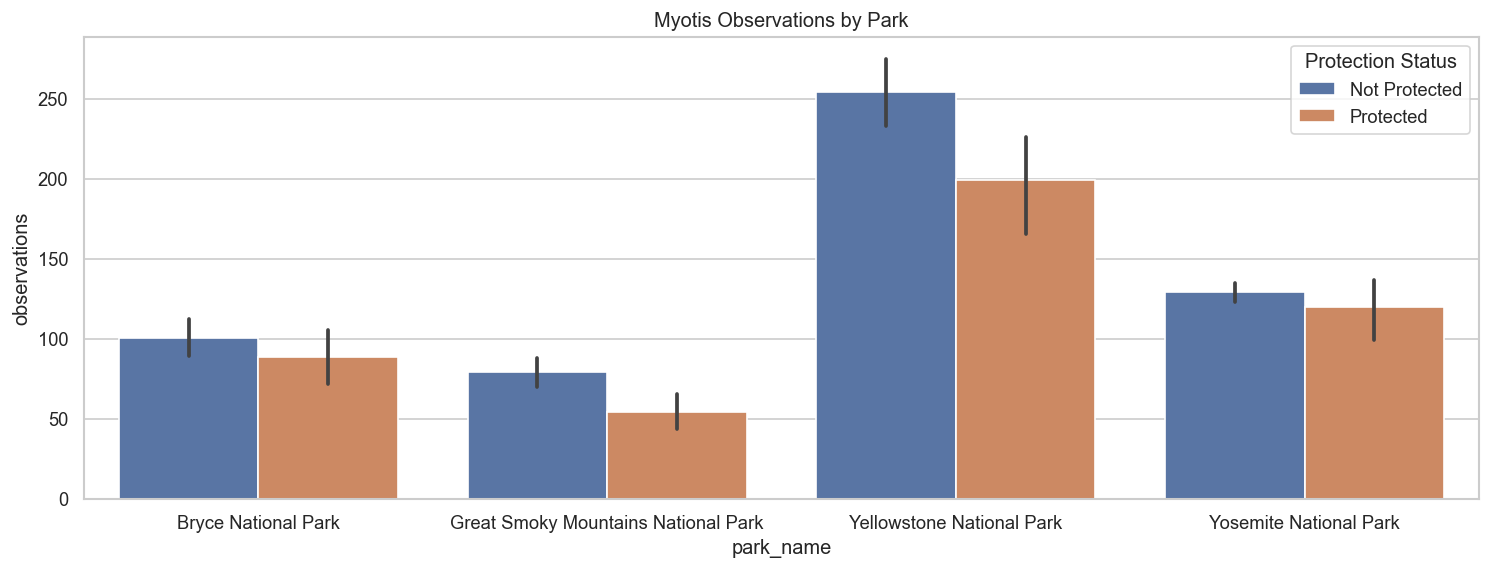

In [21]:
ax = plt.figure(figsize = (15,5))
ax = sns.barplot(x = "park_name", y = "observations", hue = "is_protected", data = bat_observations)
plt.title("Myotis Observations by Park")
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles,
           labels = ["Not Protected", "Protected"],
           title = "Protection Status")

plt.show()

In [22]:
total_obs_park = ((dfso.groupby("park_name").agg({"observations": "sum"})
                .sort_values("observations", ascending = False))
                .reset_index())
total_obs_park

,park_name,observations
0,Yellowstone National Park,1443562
1,Yosemite National Park,863332
2,Bryce National Park,576025
3,Great Smoky Mountains National Park,431820


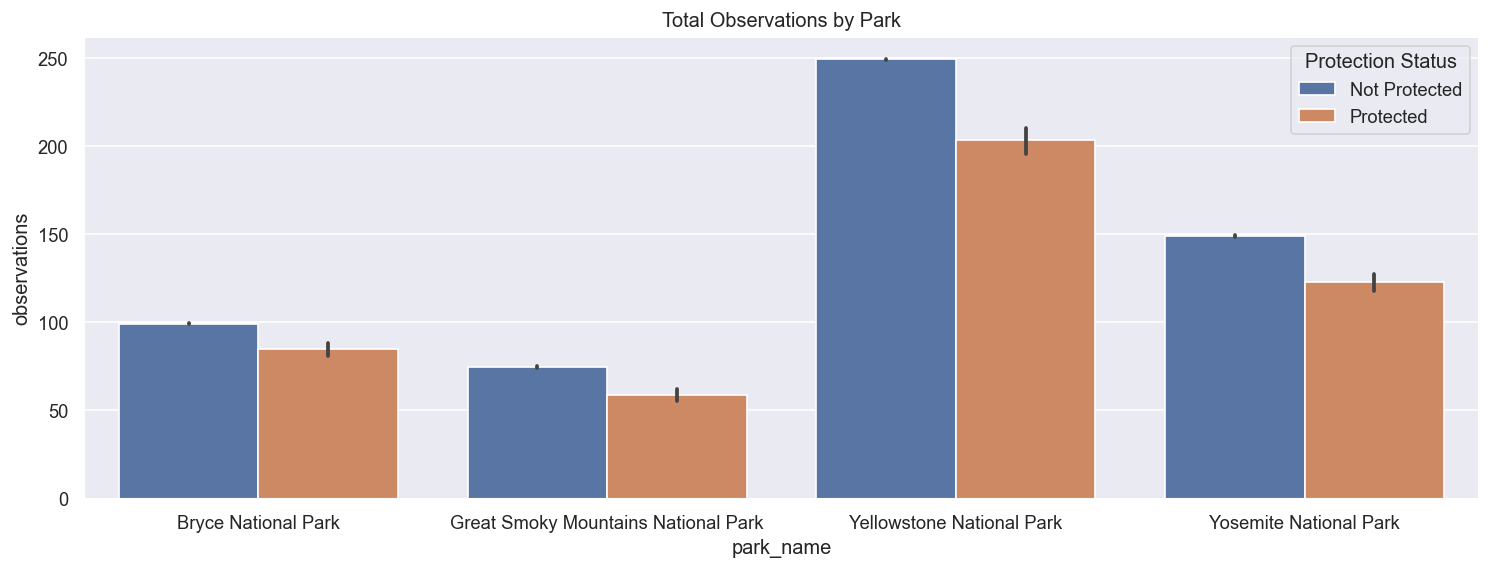

In [23]:
ax = plt.figure(figsize = (15,5))
ax = sns.barplot(x = "park_name", y = "observations", hue = "is_protected", data = dfso)
plt.title("Total Observations by Park")
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles,
           labels = ["Not Protected", "Protected"],
           title = "Protection Status")

plt.show()

Both distributions are similar. So, while the observations in Great Smoky Mountains NP were lower, the data lines up with the overall dataset, meaning that there are no anomalies as far as parks are concerned.


Looking now at the total observations of each Myotis species with the conservation status.


In [24]:
bat_obs_species = (
    bat_observations.groupby(["scientific_name", "conservation_status", "is_protected"])
    .agg({"observations": "sum"})
    .sort_values("observations", ascending = False)
    .reset_index())

<function matplotlib.pyplot.show(close=None, block=None)>

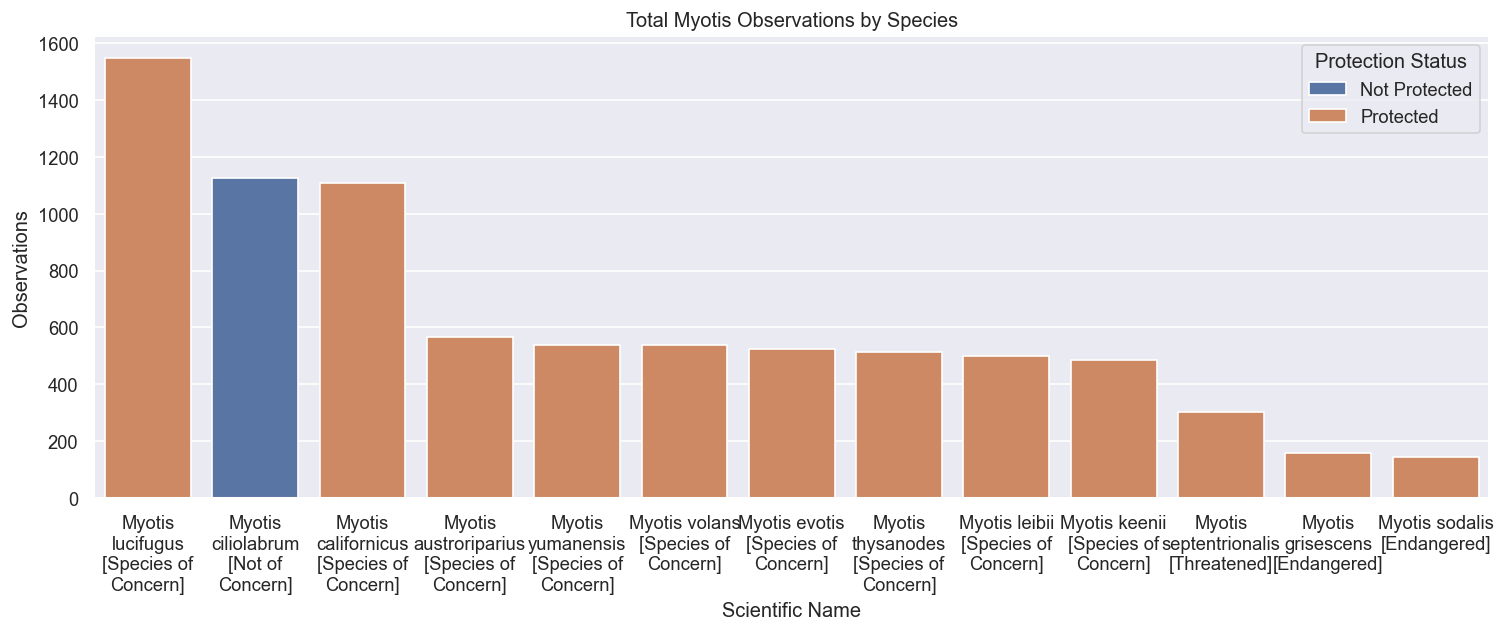

In [25]:
x_labels = [f"{Name} [{Status}]"
            for Name, Status in zip(list(bat_obs_species["scientific_name"]),
                                    list(bat_obs_species["conservation_status"]))]


x_labels = [textwrap.fill(label, width = 15)
            for label in x_labels]

ax = plt.figure(figsize=(15, 5))
ax = sns.barplot(
    x = "scientific_name",
    y = "observations",
    hue = "is_protected",
    data = bat_obs_species)

plt.title("Total Myotis Observations by Species")
plt.xlabel("Scientific Name")
plt.ylabel("Observations")

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles = handles,
           labels = ["Not Protected", "Protected"],
           title = "Protection Status")

plt.xticks(ticks = ax.get_xticks(),
            labels = x_labels)
plt.show

Looking at the distribution of "Species of Concern" observations, we see they range from 1547 (more than a species labelled "Not of Concern") and 486. So, while a lot of bat are listed protected, their numbers do not appear to be the
issue. To be sure of this, let's see how they measure up when compared to the average observation count of other species.

In [26]:
# Creating a table that shows the average observations for every species.
avg_obs = dfso.copy()
avg_obs = (avg_obs.groupby("scientific_name")
           .agg({"observations": "mean"})
           .reset_index()
           .sort_values("observations", ascending = False))
avg_obs["is_myotis"] = avg_obs["scientific_name"].str.contains(r"^Myotis")

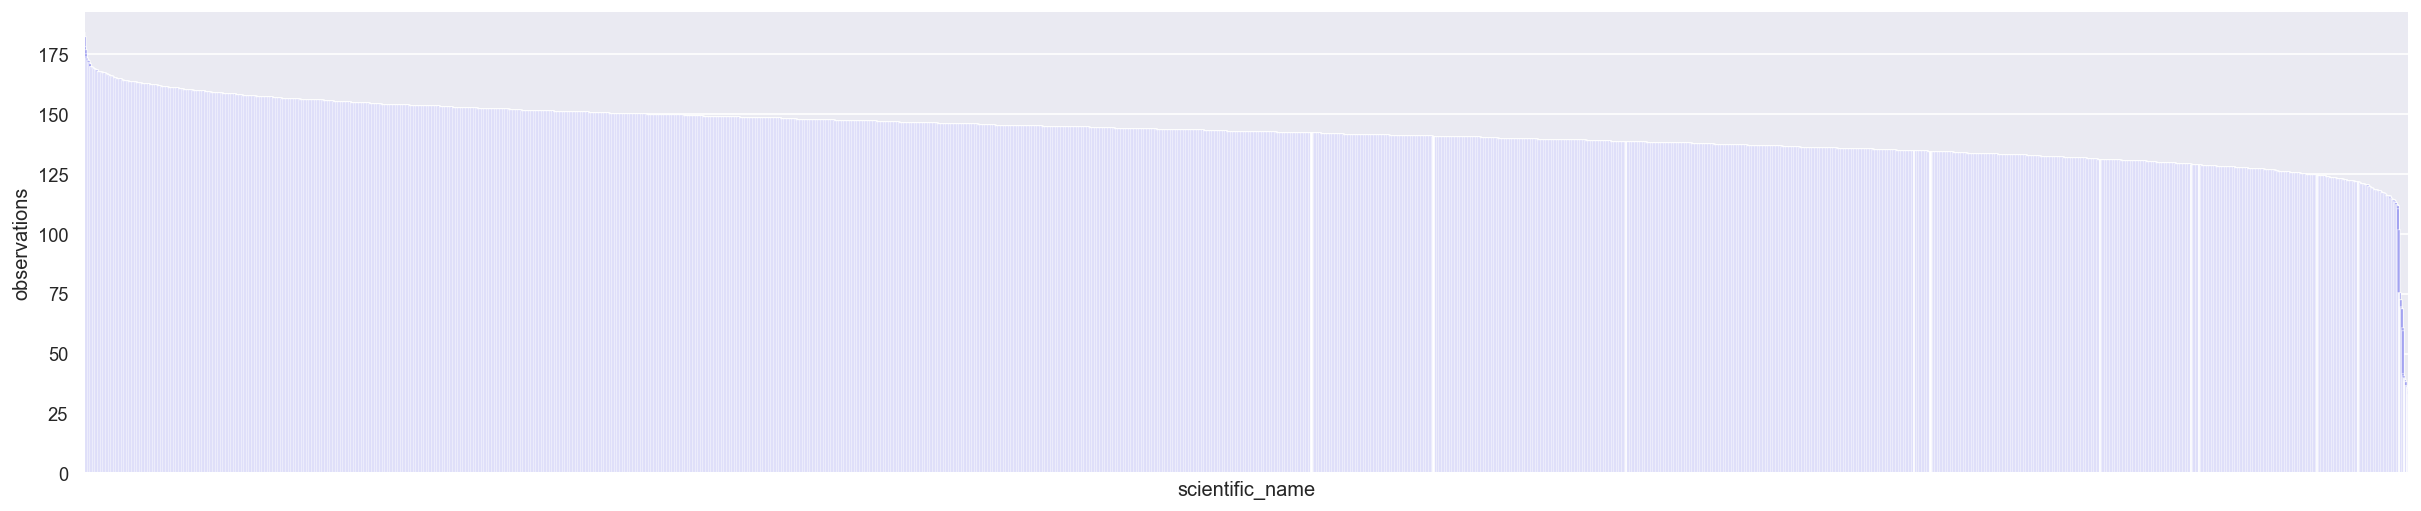

In [27]:
ax = plt.figure(figsize=(25, 5))

# Plot all bars in gray
ax = sns.barplot(
    data = avg_obs,
    x = "scientific_name",
    y = "observations",
    alpha = 0.5,
    gap = -5,
    color = "Blue",
)

sns.barplot(
    data = avg_obs[avg_obs["is_myotis"]],
    x = "scientific_name",
    y = "observations",
    color = "green",
)

# Due to the number of species on the x-axis, we will remove the x-axis ticks and labels.
ax.set_xticks([])
ax.set_xticklabels([])

plt.savefig("Output/Myotis Observations by Park.png")

# Findings
## Protection Status by Category

• Most species in the dataset are classified as Not of Concern, but certain groups show much higher protection rates.

• Birds and Mammals have disproportionately large shares of species under protection compared to other categories.

• Within these groups, many are labeled “Species of Concern”, a designation often used when evidence is insufficient to fully evaluate risk. Since our dataset is limited to observation counts, these classifications likely reflect precautionary monitoring rather than confirmed decline.

## Endangered Species

• Fourteen species are listed as Endangered across the national parks studied.

• Barplots of common and scientific names show that sightings vary substantially by park, but the relative distribution of observations is consistent (e.g., Yellowstone has higher counts across species).

• Tables organized by category highlight where endangered species are most frequently observed, making clear which groups and parks concentrate risk.

## Birds and Mammals of Concern

• After breaking down Bird and Mammal “Species of Concern” by genus:

- Birds showed no strong clustering by genus.

- Mammals revealed a striking pattern: the bat genus Myotis dominates, making up ~43% of mammal species with this designation (the next most frequent genus is only 4%).

## Bat Populations (Genus Myotis)

• Observations of Myotis species follow the same park-level distribution as total observations, suggesting no regional anomalies.

• At the species level, observation counts vary widely:

- Some Myotis species with lower counts are already classified as Threatened or Endangered.

- Others with moderate counts fall into the Species of Concern category.

• Compared to the average observation counts of all species, Myotis bats generally fall into the lower half, though not low enough to be considered statistical outliers.

## Conclusion

• The NPCA dataset confirms that Birds and Mammals receive more protection attention than other groups, largely driven by precautionary classifications such as “Species of Concern.”

• The high share of Myotis bats in this category reflects both their ecological importance and the challenges of monitoring cryptic species, rather than clear evidence of hidden risk.

• Observation patterns align with conservation status designations: species already listed as Threatened or Endangered generally show lower counts, while others flagged for monitoring display abundance levels consistent with precaution rather than immediate decline.

• Overall, the data suggests that conservation status is closely tied to observed abundance, and that monitoring efforts are effectively capturing vulnerable species.

• However, it is important to note that the “Species of Concern” classification may also reflect risks not visible in this dataset, such as disease (e.g., white-nose syndrome in bats), habitat pressures, or long-term population declines. Since this analysis is based on a relatively short observation window, it cannot fully capture these broader ecological and temporal dynamics.